<a href="https://colab.research.google.com/github/masterdelfin/masterdelfin/blob/main/Colab_Entrenamiento_Respaldo_Caso_Financiero_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrenamiento y respaldo del modelo XAI — Caso Financiero

## Trabajo
**Inteligencia Artificial Explicable para Sistemas de Apoyo a la Toma de Decisiones Empresariales**

## Primera parte experimental
**Caso financiero: aprobación de crédito usando German Credit Risk**

Este notebook permite:

1. Descargar o cargar el dataset German Credit Risk.
2. Preparar los datos.
3. Entrenar modelos de clasificación.
4. Evaluar los resultados.
5. Generar explicaciones iniciales con SHAP.
6. Respaldar en Google Drive:
   - modelos entrenados,
   - métricas,
   - predicciones,
   - gráficos,
   - archivo de configuración,
   - bitácora de ejecución.

La finalidad es que el entrenamiento pueda ser repetido, auditado y usado como evidencia metodológica del trabajo.

## 1. Montar Google Drive

Esta sección permite guardar todos los resultados del entrenamiento en una carpeta permanente de Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Instalar librerías necesarias

Se instalan librerías para modelamiento, evaluación, explicabilidad y respaldo.

> Nota: en Google Colab algunas librerías ya vienen instaladas, pero se incluyen para asegurar reproducibilidad.

In [2]:
!pip -q install xgboost shap joblib pandas scikit-learn matplotlib

## 3. Importar librerías y crear carpeta de respaldo

La carpeta se creará en:

`Mi unidad/Respaldos_TFM_XAI/modelos_caso_financiero/`

In [3]:
from pathlib import Path
from datetime import datetime
import json
import shutil
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

fecha_hora = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

CARPETA_BASE = Path('/content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero')
CARPETA_EJECUCION = CARPETA_BASE / f'entrenamiento_credito_{fecha_hora}'

CARPETA_EJECUCION.mkdir(parents=True, exist_ok=True)

print('Carpeta de respaldo creada:')
print(CARPETA_EJECUCION)

Carpeta de respaldo creada:
/content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13


## 4. Descargar dataset German Credit Risk

Se utiliza el dataset **Statlog German Credit Data**, habitualmente usado para problemas de clasificación de riesgo crediticio.

La variable objetivo original toma dos valores:

- `1`: buen riesgo crediticio.
- `2`: mal riesgo crediticio.

En este notebook se transformará a:

- `0`: buen riesgo.
- `1`: mal riesgo.

Esto permite interpretar el modelo como una predicción de **riesgo de incumplimiento o riesgo crediticio negativo**.

In [4]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

columnas = [
    'checking_status',
    'duration_months',
    'credit_history',
    'purpose',
    'credit_amount',
    'savings_status',
    'employment_since',
    'installment_rate',
    'personal_status_sex',
    'other_debtors',
    'present_residence_since',
    'property',
    'age',
    'other_installment_plans',
    'housing',
    'existing_credits',
    'job',
    'people_liable',
    'telephone',
    'foreign_worker',
    'target_original'
]

df = pd.read_csv(url, sep=' ', header=None, names=columnas)

# Transformación de objetivo:
# 1 = buen crédito -> 0
# 2 = mal crédito -> 1
df['target'] = df['target_original'].map({1: 0, 2: 1})

print('Dimensiones del dataset:', df.shape)
display(df.head())

Dimensiones del dataset: (1000, 22)


,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate,personal_status_sex,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target_original,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,67,A143,A152,2,A173,1,A192,A201,1,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,22,A143,A152,1,A173,1,A191,A201,2,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,49,A143,A152,1,A172,2,A191,A201,1,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,45,A143,A153,1,A173,2,A191,A201,1,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,53,A143,A153,2,A173,2,A191,A201,2,1


## 5. Respaldo del dataset original usado

Se guarda una copia del dataset descargado en la carpeta de respaldo, para dejar evidencia exacta de los datos usados.

In [5]:
ruta_dataset = CARPETA_EJECUCION / 'german_credit_dataset_usado.csv'
df.to_csv(ruta_dataset, index=False, encoding='utf-8-sig')

print('Dataset respaldado en:')
print(ruta_dataset)

Dataset respaldado en:
/content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13/german_credit_dataset_usado.csv


## 6. Revisión inicial de datos

Se revisan tipos de variables, distribución del objetivo y posibles valores faltantes.

In [6]:
print('Tipos de variables:')
display(df.dtypes)

print('\nValores faltantes por columna:')
display(df.isna().sum())

print('\nDistribución de la variable objetivo:')
display(df['target'].value_counts().rename(index={0: 'Buen riesgo', 1: 'Mal riesgo'}))

print('\nDistribución porcentual:')
display((df['target'].value_counts(normalize=True) * 100).round(2).rename(index={0: 'Buen riesgo', 1: 'Mal riesgo'}))

Tipos de variables:


,0
checking_status,object
duration_months,int64
credit_history,object
purpose,object
credit_amount,int64
savings_status,object
employment_since,object
installment_rate,int64
personal_status_sex,object
other_debtors,object



Valores faltantes por columna:


,0
checking_status,0
duration_months,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment_since,0
installment_rate,0
personal_status_sex,0
other_debtors,0



Distribución de la variable objetivo:


,count
target,
Buen riesgo,700
Mal riesgo,300



Distribución porcentual:


,proportion
target,
Buen riesgo,70.0
Mal riesgo,30.0


## 7. Separar variables predictoras y variable objetivo

Se elimina `target_original` para evitar duplicidad y se conserva `target` como variable objetivo binaria.

In [7]:
X = df.drop(columns=['target_original', 'target'])
y = df['target']

variables_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = X.select_dtypes(include=['object']).columns.tolist()

print('Variables numéricas:', variables_numericas)
print('Variables categóricas:', variables_categoricas)

Variables numéricas: ['duration_months', 'credit_amount', 'installment_rate', 'present_residence_since', 'age', 'existing_credits', 'people_liable']
Variables categóricas: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


## 8. División entrenamiento / prueba

Se usa una división estratificada para mantener la proporción de buenos y malos riesgos en ambos subconjuntos.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

print('Tamaño entrenamiento:', X_train.shape)
print('Tamaño prueba:', X_test.shape)

print('\nDistribución objetivo en entrenamiento:')
display(y_train.value_counts(normalize=True).round(3))

print('\nDistribución objetivo en prueba:')
display(y_test.value_counts(normalize=True).round(3))

Tamaño entrenamiento: (750, 20)
Tamaño prueba: (250, 20)

Distribución objetivo en entrenamiento:


,proportion
target,
0,0.7
1,0.3



Distribución objetivo en prueba:


,proportion
target,
0,0.7
1,0.3


## 9. Preprocesamiento

Se aplican:

- One-Hot Encoding para variables categóricas.
- Estandarización para variables numéricas.

El preprocesamiento queda integrado en el pipeline para evitar fugas de información.

In [9]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas)
    ]
)

## 10. Definir modelos

Se entrenan dos modelos, coherentes con la metodología del trabajo:

1. **XGBoost**
2. **Random Forest**

In [10]:
modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=SEED
)

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=SEED,
    class_weight='balanced'
)

pipeline_xgb = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', modelo_xgb)
])

pipeline_rf = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', modelo_rf)
])

## 11. Entrenar modelos

In [11]:
pipeline_xgb.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

print('Modelos entrenados correctamente.')

Modelos entrenados correctamente.


## 12. Evaluar modelos

Se calculan métricas relevantes para clasificación binaria:

- Accuracy / Exactitud
- Precision / Precisión
- Recall / Sensibilidad
- F1-Score
- AUC-ROC

In [12]:
def evaluar_modelo(nombre, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    metricas = {
        'modelo': nombre,
        'accuracy_exactitud': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall_sensibilidad': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'auc_roc': roc_auc_score(y_test, y_prob)
    }

    print(f'\n===== {nombre} =====')
    print(classification_report(y_test, y_pred, target_names=['Buen riesgo', 'Mal riesgo']))
    print('Matriz de confusión:')
    print(confusion_matrix(y_test, y_pred))

    return metricas, y_pred, y_prob

metricas_xgb, pred_xgb, prob_xgb = evaluar_modelo('XGBoost', pipeline_xgb, X_test, y_test)
metricas_rf, pred_rf, prob_rf = evaluar_modelo('Random Forest', pipeline_rf, X_test, y_test)

df_metricas = pd.DataFrame([metricas_xgb, metricas_rf])
display(df_metricas)


===== XGBoost =====
              precision    recall  f1-score   support

 Buen riesgo       0.80      0.89      0.84       175
  Mal riesgo       0.65      0.49      0.56        75

    accuracy                           0.77       250
   macro avg       0.73      0.69      0.70       250
weighted avg       0.76      0.77      0.76       250

Matriz de confusión:
[[155  20]
 [ 38  37]]

===== Random Forest =====
              precision    recall  f1-score   support

 Buen riesgo       0.84      0.77      0.80       175
  Mal riesgo       0.55      0.65      0.60        75

    accuracy                           0.74       250
   macro avg       0.69      0.71      0.70       250
weighted avg       0.75      0.74      0.74       250

Matriz de confusión:
[[135  40]
 [ 26  49]]


,modelo,accuracy_exactitud,precision,recall_sensibilidad,f1_score,auc_roc
0,XGBoost,0.768,0.649123,0.493333,0.560606,0.814324
1,Random Forest,0.736,0.550562,0.653333,0.597561,0.786514


In [14]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_metricas)

https://docs.google.com/spreadsheets/d/14JZvXU-VLuseGEeyTyqzN4K6QmaWCt6KF_MhDDf8MRg/edit#gid=0


## 13. Guardar métricas y predicciones

Se respaldan los resultados en archivos CSV.

In [16]:
ruta_metricas = CARPETA_EJECUCION / 'metricas_modelos.csv'
df_metricas.to_csv(ruta_metricas, index=False, encoding='utf-8-sig')

df_predicciones = X_test.copy()
df_predicciones['y_real'] = y_test.values
df_predicciones['pred_xgboost'] = pred_xgb
df_predicciones['prob_mal_riesgo_xgboost'] = prob_xgb
df_predicciones['pred_random_forest'] = pred_rf
df_predicciones['prob_mal_riesgo_random_forest'] = prob_rf

ruta_predicciones = CARPETA_EJECUCION / 'predicciones_prueba.csv'
df_predicciones.to_csv(ruta_predicciones, index=False, encoding='utf-8-sig')

print('Métricas guardadas en:', ruta_metricas)
print('Predicciones guardadas en:', ruta_predicciones)

Métricas guardadas en: /content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13/metricas_modelos.csv
Predicciones guardadas en: /content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13/predicciones_prueba.csv


## 14. Graficar curvas ROC

Estas curvas permiten comparar la capacidad discriminativa de ambos modelos.

<Figure size 800x600 with 0 Axes>

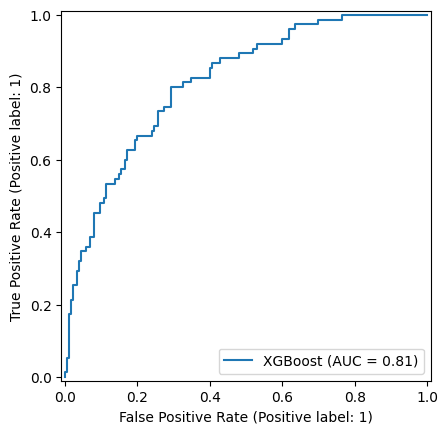

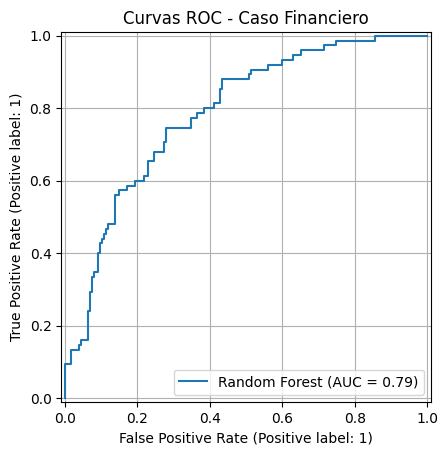

Gráfico ROC guardado en: /content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13/curvas_roc_modelos.png


In [17]:
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(pipeline_xgb, X_test, y_test, name='XGBoost')
RocCurveDisplay.from_estimator(pipeline_rf, X_test, y_test, name='Random Forest')
plt.title('Curvas ROC - Caso Financiero')
plt.grid(True)

ruta_roc = CARPETA_EJECUCION / 'curvas_roc_modelos.png'
plt.savefig(ruta_roc, dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico ROC guardado en:', ruta_roc)

## 15. Seleccionar modelo principal

Para el desarrollo del caso financiero se selecciona automáticamente el modelo con mayor AUC-ROC.

Este criterio puede cambiarse si se decide priorizar sensibilidad, precisión o interpretabilidad.

In [18]:
mejor_fila = df_metricas.sort_values(by='auc_roc', ascending=False).iloc[0]
mejor_modelo_nombre = mejor_fila['modelo']

if mejor_modelo_nombre == 'XGBoost':
    mejor_pipeline = pipeline_xgb
else:
    mejor_pipeline = pipeline_rf

print('Modelo seleccionado:', mejor_modelo_nombre)
display(mejor_fila)

Modelo seleccionado: XGBoost


,0
modelo,XGBoost
accuracy_exactitud,0.768
precision,0.649123
recall_sensibilidad,0.493333
f1_score,0.560606
auc_roc,0.814324


## 16. Respaldo de modelos entrenados

Se guardan los pipelines completos, incluyendo preprocesamiento y modelo.

In [19]:
ruta_modelo_xgb = CARPETA_EJECUCION / 'pipeline_xgboost.joblib'
ruta_modelo_rf = CARPETA_EJECUCION / 'pipeline_random_forest.joblib'
ruta_modelo_principal = CARPETA_EJECUCION / 'modelo_principal.joblib'

joblib.dump(pipeline_xgb, ruta_modelo_xgb)
joblib.dump(pipeline_rf, ruta_modelo_rf)
joblib.dump(mejor_pipeline, ruta_modelo_principal)

print('Modelos respaldados:')
print(ruta_modelo_xgb)
print(ruta_modelo_rf)
print(ruta_modelo_principal)

Modelos respaldados:
/content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13/pipeline_xgboost.joblib
/content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13/pipeline_random_forest.joblib
/content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13/modelo_principal.joblib


## 17. Preparar datos transformados para SHAP

Para explicar modelos basados en árboles, se obtiene la matriz ya preprocesada y los nombres de variables generados por One-Hot Encoding.

In [20]:
preprocesador_entrenado = mejor_pipeline.named_steps['preprocesador']
modelo_entrenado = mejor_pipeline.named_steps['modelo']

X_train_trans = preprocesador_entrenado.transform(X_train)
X_test_trans = preprocesador_entrenado.transform(X_test)

# Convertir a matriz densa si es necesario
if hasattr(X_train_trans, 'toarray'):
    X_train_trans = X_train_trans.toarray()
if hasattr(X_test_trans, 'toarray'):
    X_test_trans = X_test_trans.toarray()

feature_names = preprocesador_entrenado.get_feature_names_out()

X_train_trans_df = pd.DataFrame(X_train_trans, columns=feature_names)
X_test_trans_df = pd.DataFrame(X_test_trans, columns=feature_names)

print('Datos transformados para SHAP:')
display(X_test_trans_df.head())

Datos transformados para SHAP:


,num__duration_months,num__credit_amount,num__installment_rate,num__present_residence_since,num__age,num__existing_credits,num__people_liable,cat__checking_status_A11,cat__checking_status_A12,cat__checking_status_A13,...,cat__housing_A152,cat__housing_A153,cat__job_A171,cat__job_A172,cat__job_A173,cat__job_A174,cat__telephone_A191,cat__telephone_A192,cat__foreign_worker_A201,cat__foreign_worker_A202
0,2.293418,1.447093,0.045112,1.059204,1.600501,1.075289,2.302720,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,-0.742435,-0.346099,0.935476,1.059204,0.144397,-0.708929,-0.434269,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,-1.248410,-0.945929,-0.845253,1.059204,-1.129694,-0.708929,-0.434269,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.269516,0.959893,0.935476,-0.750370,-0.765668,1.075289,-0.434269,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,0.269516,-0.197901,0.935476,-1.655157,-0.583655,-0.708929,-0.434269,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


## 18. Explicabilidad con SHAP

Se calcula SHAP para el modelo principal.

Para evitar tiempos excesivos, se usa una muestra del conjunto de prueba.

In [21]:
import shap

muestra_shap = X_test_trans_df.sample(
    n=min(150, len(X_test_trans_df)),
    random_state=SEED
)

explainer = shap.TreeExplainer(modelo_entrenado)
shap_values = explainer.shap_values(muestra_shap)

print('Valores SHAP calculados.')

Valores SHAP calculados.


## 19. Gráfico SHAP de importancia global

Este gráfico muestra las variables con mayor influencia promedio en las predicciones del modelo.

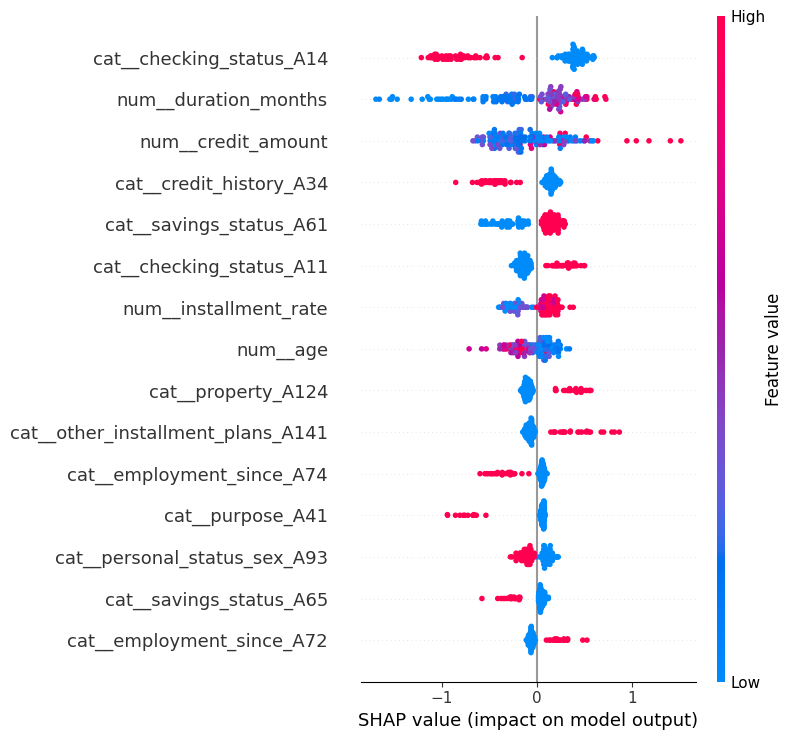

Gráfico SHAP guardado en: /content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13/shap_summary_importancia_global.png


In [22]:
plt.figure()
shap.summary_plot(shap_values, muestra_shap, show=False, max_display=15)
ruta_shap_summary = CARPETA_EJECUCION / 'shap_summary_importancia_global.png'
plt.savefig(ruta_shap_summary, dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico SHAP guardado en:', ruta_shap_summary)

## 20. Tabla de importancia SHAP

Se calcula el valor absoluto medio de SHAP por variable.

In [23]:
shap_importance = np.abs(shap_values).mean(axis=0)

df_shap_importance = pd.DataFrame({
    'variable_transformada': feature_names,
    'importancia_shap_media_absoluta': shap_importance
}).sort_values(by='importancia_shap_media_absoluta', ascending=False)

ruta_shap_importance = CARPETA_EJECUCION / 'shap_importancia_variables.csv'
df_shap_importance.to_csv(ruta_shap_importance, index=False, encoding='utf-8-sig')

display(df_shap_importance.head(20))

print('Tabla SHAP guardada en:', ruta_shap_importance)

,variable_transformada,importancia_shap_media_absoluta
10,cat__checking_status_A14,0.574795
0,num__duration_months,0.433492
1,num__credit_amount,0.319696
15,cat__credit_history_A34,0.244267
26,cat__savings_status_A61,0.216872
7,cat__checking_status_A11,0.183298
2,num__installment_rate,0.171534
4,num__age,0.154995
46,cat__property_A124,0.149487
47,cat__other_installment_plans_A141,0.130089


Tabla SHAP guardada en: /content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13/shap_importancia_variables.csv


### Importancia de las variables (Feature Importance) para XGBoost (usando valores SHAP)

El análisis de la importancia de las variables, fundamental para comprender qué características del *dataset* influyen más en las predicciones del modelo, ya se ha realizado utilizando los valores SHAP. Los valores SHAP (SHapley Additive exPlanations) son un enfoque de la teoría de juegos que explica la salida de cualquier modelo de *machine learning*.

In [29]:
print('Las variables más importantes para el modelo XGBoost (según SHAP) son:')
display(df_shap_importance.head(10))

Las variables más importantes para el modelo XGBoost (según SHAP) son:


,variable_transformada,importancia_shap_media_absoluta
10,cat__checking_status_A14,0.574795
0,num__duration_months,0.433492
1,num__credit_amount,0.319696
15,cat__credit_history_A34,0.244267
26,cat__savings_status_A61,0.216872
7,cat__checking_status_A11,0.183298
2,num__installment_rate,0.171534
4,num__age,0.154995
46,cat__property_A124,0.149487
47,cat__other_installment_plans_A141,0.130089


## 21. Exportar configuración de ejecución

Se guarda un archivo JSON con la configuración principal del entrenamiento.

In [25]:
configuracion = {
    'fecha_hora_ejecucion': fecha_hora,
    'semilla': SEED,
    'dataset': 'Statlog German Credit Data',
    'url_dataset': url,
    'variable_objetivo': 'target',
    'codificacion_objetivo': {
        '0': 'buen riesgo crediticio',
        '1': 'mal riesgo crediticio'
    },
    'test_size': 0.25,
    'modelo_principal': mejor_modelo_nombre,
    'variables_numericas': variables_numericas,
    'variables_categoricas': variables_categoricas,
    'metricas': df_metricas.to_dict(orient='records')
}

ruta_config = CARPETA_EJECUCION / 'configuracion_entrenamiento.json'

with open(ruta_config, 'w', encoding='utf-8') as f:
    json.dump(configuracion, f, ensure_ascii=False, indent=4)

print('Configuración guardada en:', ruta_config)

Configuración guardada en: /content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13/configuracion_entrenamiento.json


## 22. Crear bitácora metodológica

Este archivo resume qué se hizo y puede servir como respaldo para la redacción del capítulo metodológico.

In [26]:
texto_bitacora = f'''
BITÁCORA DE ENTRENAMIENTO — CASO FINANCIERO

Fecha y hora de ejecución: {fecha_hora}
Dataset utilizado: Statlog German Credit Data / German Credit Risk
Objetivo del modelo: clasificar riesgo crediticio.
Variable objetivo:
- 0 = buen riesgo crediticio
- 1 = mal riesgo crediticio

Modelos entrenados:
- XGBoost
- Random Forest

Modelo principal seleccionado según AUC-ROC:
- {mejor_modelo_nombre}

Métricas obtenidas:
{df_metricas.to_string(index=False)}

Archivos generados:
- german_credit_dataset_usado.csv
- metricas_modelos.csv
- predicciones_prueba.csv
- curvas_roc_modelos.png
- shap_summary_importancia_global.png
- shap_importancia_variables.csv
- pipeline_xgboost.joblib
- pipeline_random_forest.joblib
- modelo_principal.joblib
- configuracion_entrenamiento.json

Observación:
Los resultados dependen de la semilla aleatoria, la partición de datos, los hiperparámetros y la versión de las librerías.
Para efectos académicos, se recomienda reportar estos elementos en la sección metodológica.
'''

ruta_bitacora = CARPETA_EJECUCION / 'bitacora_metodologica.txt'

with open(ruta_bitacora, 'w', encoding='utf-8') as f:
    f.write(texto_bitacora)

print('Bitácora metodológica guardada en:')
print(ruta_bitacora)

Bitácora metodológica guardada en:
/content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13/bitacora_metodologica.txt


## 23. Crear respaldo comprimido ZIP

Se comprime la carpeta completa de la ejecución para facilitar descarga o traslado.

In [27]:
ruta_zip = shutil.make_archive(
    base_name=str(CARPETA_EJECUCION),
    format='zip',
    root_dir=str(CARPETA_EJECUCION)
)

print('Archivo ZIP creado:')
print(ruta_zip)

Archivo ZIP creado:
/content/drive/MyDrive/Respaldos_TFM_XAI/modelos_caso_financiero/entrenamiento_credito_2026-05-04_05-21-13.zip


## 24. Verificación final

Se listan todos los archivos generados.

In [28]:
print('Archivos generados en la ejecución:')
for archivo in sorted(CARPETA_EJECUCION.glob('*')):
    print('-', archivo.name)

Archivos generados en la ejecución:
- bitacora_metodologica.txt
- configuracion_entrenamiento.json
- curvas_roc_modelos.png
- german_credit_dataset_usado.csv
- metricas_modelos.csv
- modelo_principal.joblib
- pipeline_random_forest.joblib
- pipeline_xgboost.joblib
- predicciones_prueba.csv
- shap_importancia_variables.csv
- shap_summary_importancia_global.png


# Uso sugerido en el trabajo

Este notebook puede respaldar empíricamente el apartado:

**4. Desarrollo específico — Parte I: Caso financiero: aprobación de crédito**

Los resultados exportados permiten documentar:

- dataset utilizado,
- preparación de datos,
- modelos entrenados,
- métricas de evaluación,
- comparación entre modelos,
- selección del modelo principal,
- explicación global con SHAP,
- respaldo reproducible de la ejecución.